# Introduction
In this project, we aim to evaluate the feasibility of using public historical global climate datasets to predict traffic volume, in contrast to direct measurement and observation of weather conditions.

The datasets used in this project include:
- Metro Interstate Traffic Volume (https://archive.ics.uci.edu/dataset/492/metro+interstate+traffic+volume)
- ERA5 hourly data on single levels from 1940 to present (https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels)

We'll build a model that predicts traffic volume from direct weather measurements according to weather conditions, both "main" and "descriptive", and another model that predicts traffic volume from historical global climate data. Finally, we'll compare their performances according to weather data and statistical model used.

# 1. Import modules

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. Data collection
Note that the ERA5 hourly data was requested year-by-year, then converted from .grib to .csv using a custom-written ``grib2csv.py`` script beforehand. Even though this is in fact a significant part of the data cleaning process, the conversion process will be dropped and the data cleaning part will focus on ironing out the final details before use in modeling.

Moreover, the coordinates input for the ERA5 hourly data is determined by locating the coordinates of MN DoT ATR station 301 (specifically Route I-94, Reference post 239+00.922) used in traffic volume data collection from the Roadway Project Mapping Application (https://www.dot.state.mn.us/roadway/data/rpma.html).

In [2]:
traffic = pd.read_csv('Metro_Interstate_Traffic_Volume.csv')
traffic.head()

,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time
0,5545,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,02-10-2012 09:00
1,4516,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,02-10-2012 10:00
2,4767,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 11:00
3,5026,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 12:00
4,4918,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,02-10-2012 13:00


In [3]:
ERA5_2012 = pd.read_csv('ERA5_2012.csv')
ERA5_2013 = pd.read_csv('ERA5_2013.csv')
ERA5_2014 = pd.read_csv('ERA5_2014.csv')
ERA5_2015 = pd.read_csv('ERA5_2015.csv')
ERA5_2016 = pd.read_csv('ERA5_2016.csv')
ERA5_2017 = pd.read_csv('ERA5_2017.csv')
ERA5_2018 = pd.read_csv('ERA5_2018.csv')

# Merge all datasets and delete separate dataframes
ERA5 = pd.concat([ERA5_2012, ERA5_2013, ERA5_2014, ERA5_2015, ERA5_2016, ERA5_2017, ERA5_2018],
                 axis=0, ignore_index=True)

del ERA5_2012, ERA5_2013, ERA5_2014, ERA5_2015, ERA5_2016, ERA5_2017, ERA5_2018
ERA5.head()

,t2m,tcc,lcc,mcc,hcc,valid_time,ptype,tp,sf,cp,lsp
0,275.64478,0.945885,0.349785,0.220996,0.924800,2012-01-01 00:00:00,8.0,0.000000,0.000000,0.000000,0.000000
1,274.96802,0.992929,0.787845,0.821806,0.972085,2012-01-01 01:00:00,1.0,0.000077,0.000000,0.000070,0.000008
2,275.06910,1.000000,0.882888,0.981989,0.974361,2012-01-01 02:00:00,1.0,0.000099,0.000000,0.000040,0.000060
3,273.99487,0.999468,0.689093,0.996290,0.954493,2012-01-01 03:00:00,7.0,0.000411,0.000049,0.000118,0.000293
4,274.07740,1.000000,0.914553,1.000000,0.993137,2012-01-01 04:00:00,6.0,0.001072,0.000808,0.000219,0.000853


# 3.1 Data exploration (``traffic``)

## Check NULL and duplicate values for dataset

In [5]:
traffic.isnull().sum()

traffic_volume             0
holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
dtype: int64

There is no NULL values except for holiday, which seems to indicate the lack of holidays.

In [6]:
traffic.duplicated().sum()

17

Let's remove duplicates and change NULL values to 'None':

In [4]:
traffic.drop_duplicates(inplace=True, ignore_index=True)
traffic.holiday = traffic.holiday.fillna('None')

traffic.head()

,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time
0,5545,None,288.28,0.0,0.0,40,Clouds,scattered clouds,02-10-2012 09:00
1,4516,None,289.36,0.0,0.0,75,Clouds,broken clouds,02-10-2012 10:00
2,4767,None,289.58,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 11:00
3,5026,None,290.13,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 12:00
4,4918,None,291.14,0.0,0.0,75,Clouds,broken clouds,02-10-2012 13:00


## Check qualitative variables in dataset

In [8]:
traffic.holiday.value_counts()

holiday
None                         48126
Labor Day                        7
Thanksgiving Day                 6
Christmas Day                    6
New Years Day                    6
Martin Luther King Jr Day        6
Columbus Day                     5
Veterans Day                     5
Washingtons Birthday             5
Memorial Day                     5
Independence Day                 5
State Fair                       5
Name: count, dtype: int64

In [9]:
traffic.weather_main.value_counts()

weather_main
Clouds          15158
Clear           13384
Mist             5949
Rain             5672
Snow             2875
Drizzle          1820
Haze             1360
Thunderstorm     1033
Fog               912
Smoke              20
Squall              4
Name: count, dtype: int64

In [10]:
traffic.weather_description.value_counts()

weather_description
sky is clear                           11659
mist                                    5949
overcast clouds                         5079
broken clouds                           4663
scattered clouds                        3460
light rain                              3372
few clouds                              1956
light snow                              1945
Sky is Clear                            1725
moderate rain                           1664
haze                                    1360
light intensity drizzle                 1099
fog                                      912
proximity thunderstorm                   673
drizzle                                  651
heavy snow                               616
heavy intensity rain                     467
snow                                     293
proximity shower rain                    136
thunderstorm                             124
heavy intensity drizzle                   64
thunderstorm with heavy rain       

Notice that that there are two separate values denoted "sky is clear" and "Sky is Clear." We'll deal with that later.

## Check quantitative variable distribution

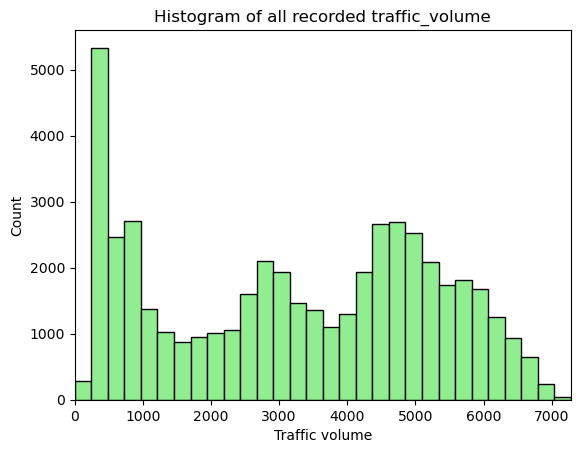

In [13]:
# Traffic volume distribution
plt.title("Histogram of all recorded traffic_volume")
plt.xlim(traffic.traffic_volume.min(), traffic.traffic_volume.max())
plt.xlabel("Traffic volume")
plt.ylabel("Count")

plt.hist(traffic.traffic_volume, color='lightgreen', ec='black', bins=30)

plt.show()

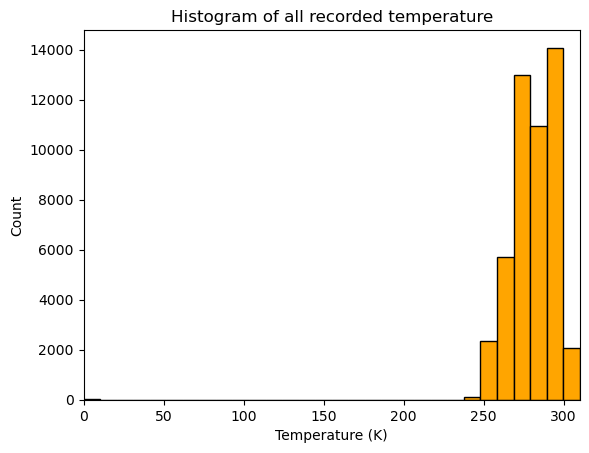

In [110]:
# Temperature distribution
plt.title("Histogram of all recorded temperature")
plt.xlim(traffic.temp.min(), traffic.temp.max())
plt.xlabel("Temperature (K)")
plt.ylabel("Count")

plt.hist(traffic.temp, color='orange', ec='black', bins=30)

plt.show()

It would appear there exists an outlier at T = 0K, which is impossible! 
This is likely a measurement error. Let's try ignoring temperatures below 200K:

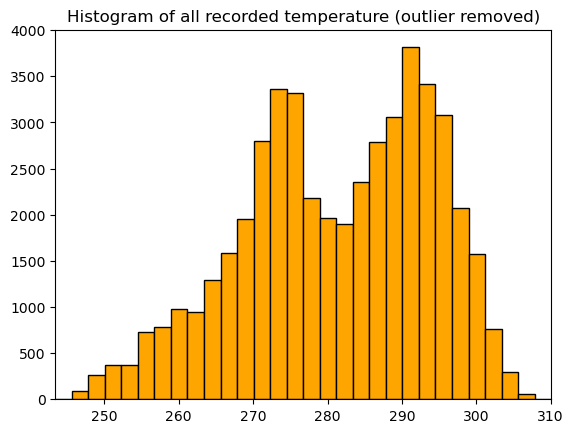

In [111]:
# Temperature distribution
plt.title("Histogram of all recorded temperature (outlier removed)")
plt.xlim(traffic.temp[traffic.temp > 200].min(), traffic.temp.max())
plt.hist(traffic.temp[traffic.temp > 200], color='orange', ec='black', bins=30)

plt.show()

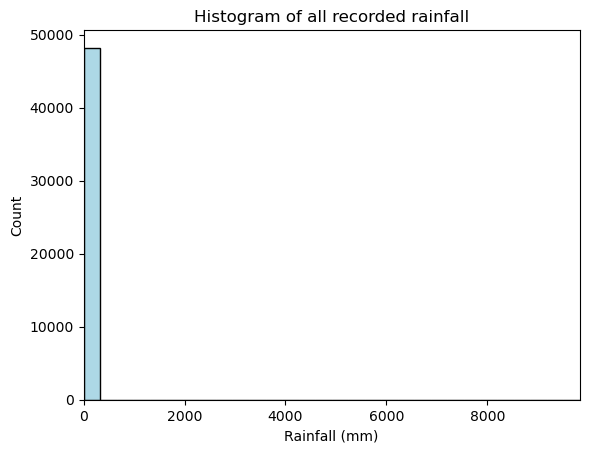

In [112]:
# Rainfall distribution
plt.title("Histogram of all recorded rainfall")
plt.xlim(traffic.rain_1h.min(), traffic.rain_1h.max())
plt.xlabel("Rainfall (mm)")
plt.ylabel("Count")

plt.hist(traffic.rain_1h, color='lightblue', ec='black', bins=30)

plt.show()

Most of the data, as expected, are bunched up at 0mm. There also seems to be data implying the device recorded 10000mm (10m) of rainfall at some point. Let's try removing it.
What if we remove the outlier and scale the y axis logarithmically? Same logic applies for snowfall data.

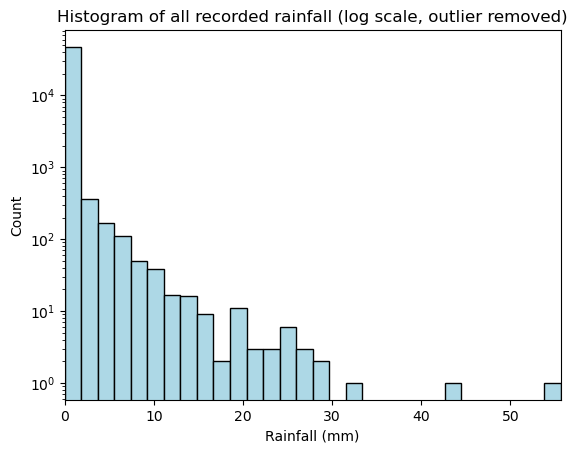

In [39]:
# Rainfall distribution
plt.title("Histogram of all recorded rainfall (log scale, outlier removed)")
plt.xlim(traffic.rain_1h.min(), traffic.rain_1h[traffic.rain_1h < 8000].max())
plt.xlabel("Rainfall (mm)")
plt.ylabel("Count")

plt.hist(traffic.rain_1h[traffic.rain_1h < 8000], color='lightblue', ec='black', bins=30)
plt.yscale('log')

plt.show()

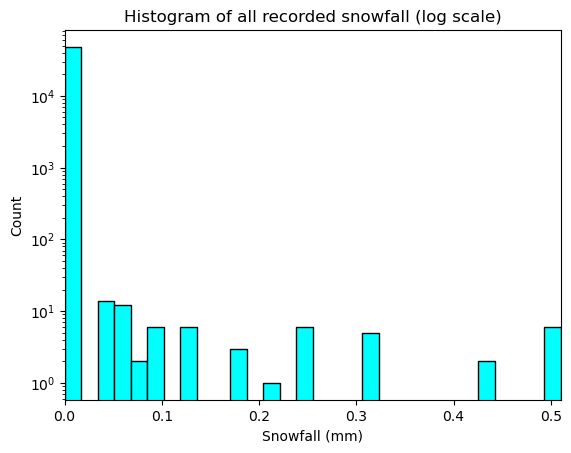

In [40]:
# Snowfall distribution
plt.title("Histogram of all recorded snowfall (log scale)")
plt.xlim(traffic.snow_1h.min(), traffic.snow_1h.max())
plt.xlabel("Snowfall (mm)")
plt.ylabel("Count")

plt.hist(traffic.snow_1h, color='cyan', ec='black', bins=30)
plt.yscale('log')

plt.show()

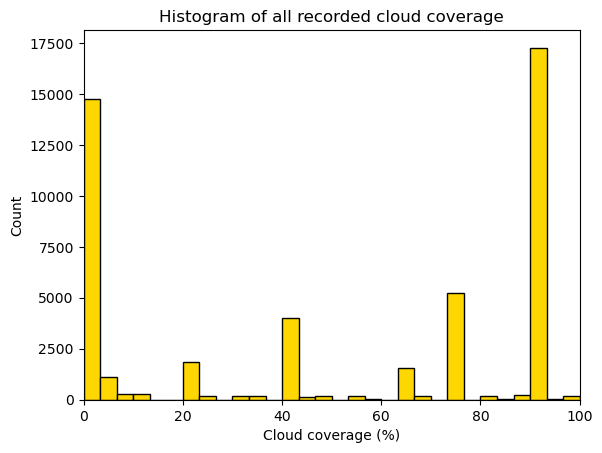

In [44]:
# Cloud coverage distribution
plt.title("Histogram of all recorded cloud coverage")
plt.xlim(traffic.clouds_all.min(), traffic.clouds_all.max())
plt.xlabel("Cloud coverage (%)")
plt.ylabel("Count")

plt.hist(traffic.clouds_all, color='gold', ec='black', bins=30)

plt.show()

In summary, we found outliers in the temperature column and the rainfall column, which will be removed accordingly.

## Check relationships between variables

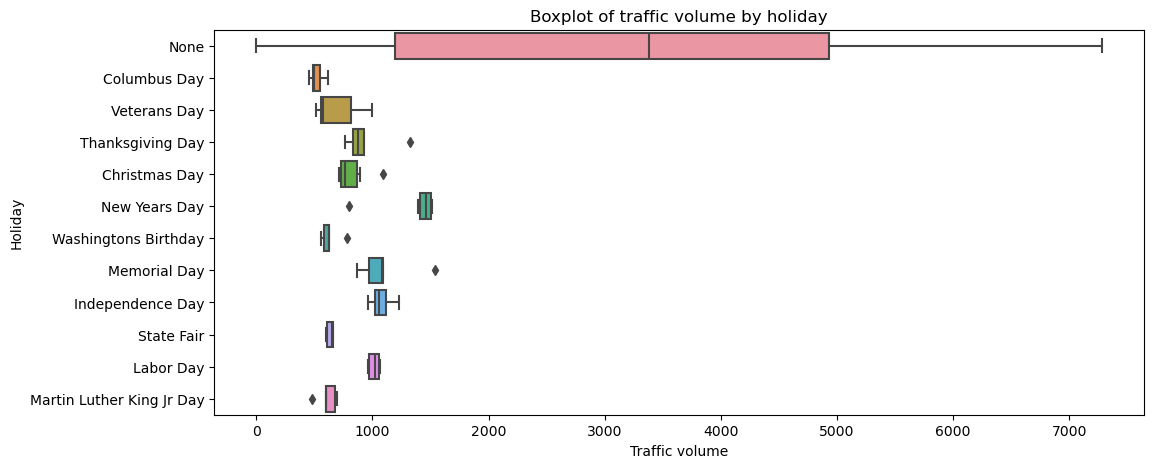

In [11]:
# Traffic volume by holiday
plt.figure(figsize=(12, 5))
sns.boxplot(x='traffic_volume', y='holiday', data=traffic)

plt.title('Boxplot of traffic volume by holiday')
plt.xlabel('Traffic volume')
plt.ylabel('Holiday')

plt.show()

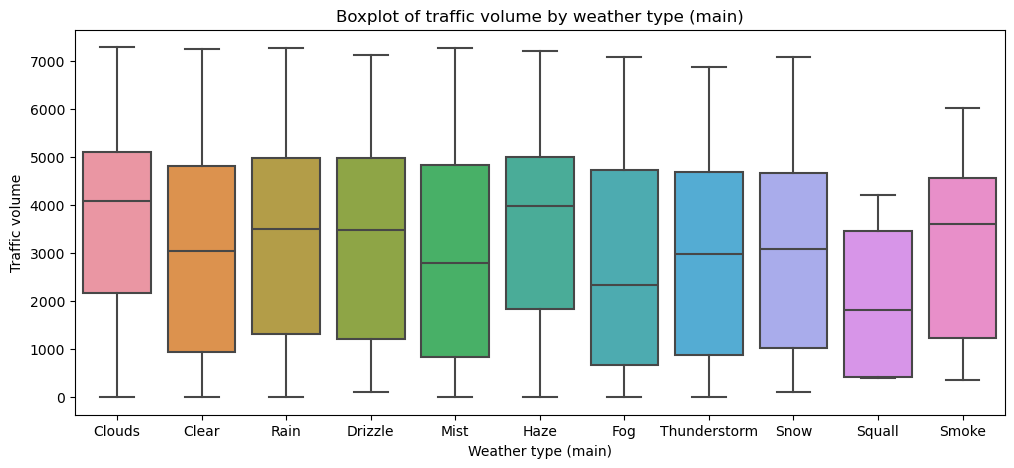

In [135]:
# Traffic volume by weather types
plt.figure(figsize=(12, 5))
sns.boxplot(x='weather_main', y='traffic_volume', data=traffic)

plt.title('Boxplot of traffic volume by weather type (main)')
plt.xlabel('Weather type (main)')
plt.ylabel('Traffic volume')

plt.show()

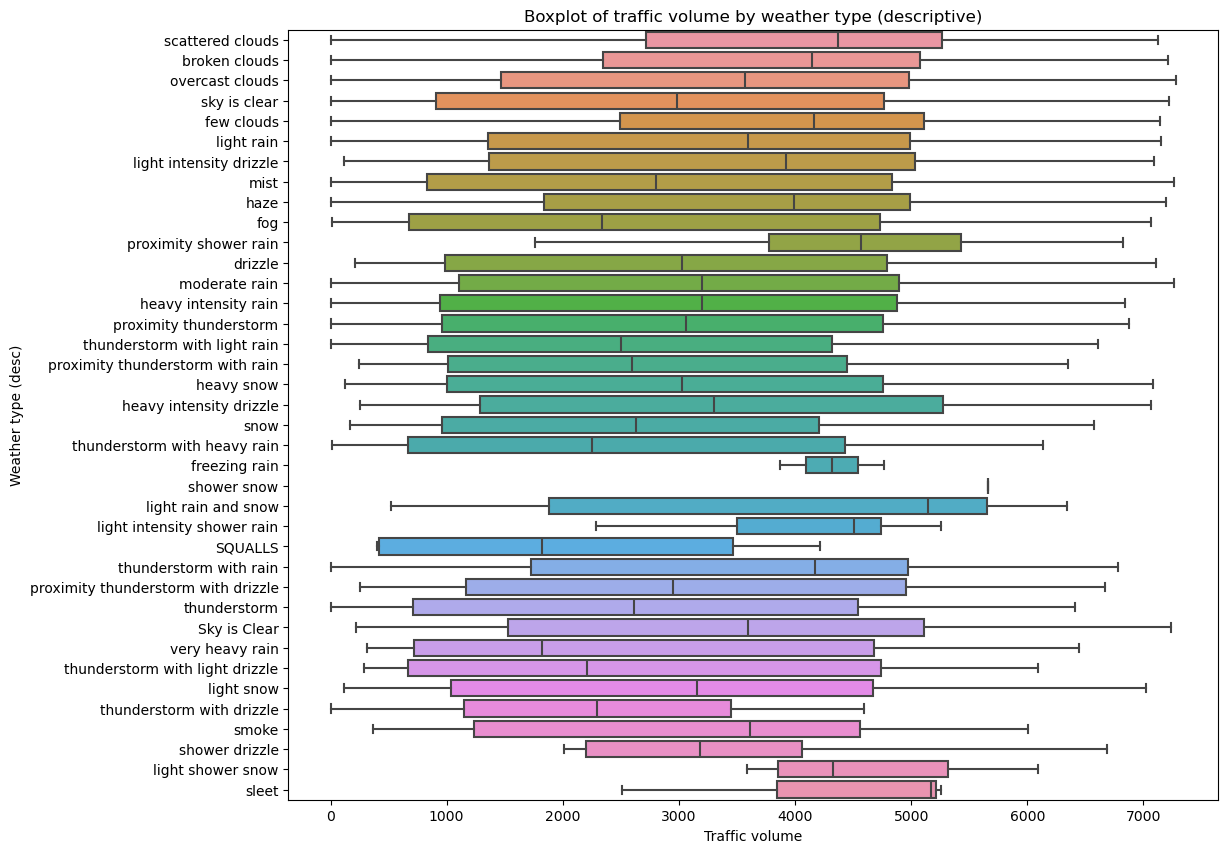

In [132]:
plt.figure(figsize=(12, 10))
sns.boxplot(x='traffic_volume', y='weather_description', data=traffic)

plt.title('Boxplot of traffic volume by weather type (descriptive)')
plt.xlabel('Traffic volume')
plt.ylabel('Weather type (desc)')

plt.show()

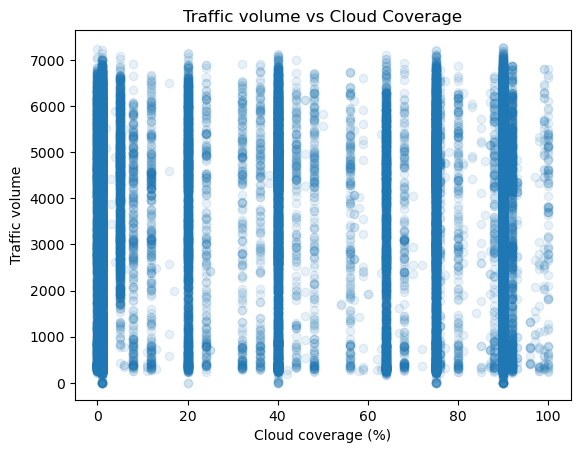

In [136]:
# Traffic volume by cloud coverage
plt.scatter(traffic.clouds_all, traffic.traffic_volume, alpha=0.1)
plt.title('Traffic volume vs Cloud Coverage')

plt.xlabel('Cloud coverage (%)')
plt.ylabel('Traffic volume')

plt.show()

In summary:
- Expect low correlation from cloud coverage.
- Holidays massively reduce traffic volume and different holidays have different impacts.
- Weather conditions DO have an impact on traffic volume. Detailed weather accounts results in more impact variation in traffic volume.

# 3.2 Data cleaning and Feature engineering (``traffic``)

## Outlier and duplicate removal for qualitative columns

In [5]:
# Drop all rows with temperature < 200K and precipitation > 8000 mm
traffic.drop(traffic[traffic.temp < 200].index, inplace=True)
traffic.drop(traffic[traffic.rain_1h > 8000].index, inplace=True)
traffic.reset_index(inplace=True, drop=True)

# Rename "Sky is Clear" to "sky is clear"
traffic.weather_description = traffic.weather_description.str.replace('Sky is Clear', 'sky is clear')

traffic.head()

,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time
0,5545,None,288.28,0.0,0.0,40,Clouds,scattered clouds,02-10-2012 09:00
1,4516,None,289.36,0.0,0.0,75,Clouds,broken clouds,02-10-2012 10:00
2,4767,None,289.58,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 11:00
3,5026,None,290.13,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 12:00
4,4918,None,291.14,0.0,0.0,75,Clouds,broken clouds,02-10-2012 13:00


## One hot encoding for quantitative columns

Also, drop 'None' column as it is not used.

In [6]:
# One hot encoding for holiday values
dummy_holiday = pd.get_dummies(traffic.holiday)
dummy_holiday.drop(columns=['None'], inplace=True)

dummy_holiday.head()

,Christmas Day,Columbus Day,Independence Day,Labor Day,Martin Luther King Jr Day,Memorial Day,New Years Day,State Fair,Thanksgiving Day,Veterans Day,Washingtons Birthday
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False


In [7]:
# One hot encoding for holiday weather values (main)
dummy_weaMain = pd.get_dummies(traffic.weather_main)
dummy_weaMain.head()

,Clear,Clouds,Drizzle,Fog,Haze,Mist,Rain,Smoke,Snow,Squall,Thunderstorm
0,False,True,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,False,False,False,False,False
3,False,True,False,False,False,False,False,False,False,False,False
4,False,True,False,False,False,False,False,False,False,False,False


In [8]:
# One hot encoding for weather values (descriptive)
dummy_weaDesc = pd.get_dummies(traffic.weather_description)
dummy_weaDesc.head()

,SQUALLS,broken clouds,drizzle,few clouds,fog,freezing rain,haze,heavy intensity drizzle,heavy intensity rain,heavy snow,...,sleet,smoke,snow,thunderstorm,thunderstorm with drizzle,thunderstorm with heavy rain,thunderstorm with light drizzle,thunderstorm with light rain,thunderstorm with rain,very heavy rain
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Split date_time column into year, month, day, hour, and day of the week and put it into traffic dataframe

In [9]:
traffic.date_time = pd.to_datetime(traffic.date_time, dayfirst=True)

traffic['year'] = traffic.date_time.dt.year
traffic['month'] = traffic.date_time.dt.month
traffic['day'] = traffic.date_time.dt.day
traffic['hour'] = traffic.date_time.dt.hour
traffic['day_of_week'] = traffic.date_time.dt.day_name()

traffic.head()

,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,year,month,day,hour,day_of_week
0,5545,None,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,2012,10,2,9,Tuesday
1,4516,None,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,2012,10,2,10,Tuesday
2,4767,None,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,2012,10,2,11,Tuesday
3,5026,None,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,2012,10,2,12,Tuesday
4,4918,None,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,2012,10,2,13,Tuesday


## One hot encoding for hour, day of week and month of year

In [10]:
# One hot encoding for days of the week
dummy_dayOfWeek = pd.get_dummies(traffic.day_of_week)
dummy_dayOfWeek.head()

,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
0,False,False,False,False,False,True,False
1,False,False,False,False,False,True,False
2,False,False,False,False,False,True,False
3,False,False,False,False,False,True,False
4,False,False,False,False,False,True,False


In [11]:
# One hot encoding for hour of the day
dummy_hour = pd.get_dummies(traffic.hour)
dummy_hour.columns = [f"hr{col}" for col in dummy_hour.columns] # Rename columns

dummy_hour.head()

,hr0,hr1,hr2,hr3,hr4,hr5,hr6,hr7,hr8,hr9,...,hr14,hr15,hr16,hr17,hr18,hr19,hr20,hr21,hr22,hr23
0,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [12]:
# One hot encoding for months of the year
dummy_month = pd.get_dummies(traffic.month)

dummy_month.columns = [f"mo{col}" for col in dummy_month.columns] # Rename columns
dummy_month.head()

,mo1,mo2,mo3,mo4,mo5,mo6,mo7,mo8,mo9,mo10,mo11,mo12
0,False,False,False,False,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,True,False,False
4,False,False,False,False,False,False,False,False,False,True,False,False


## Rearrange columns

In [13]:
traffic = traffic[['date_time', 'year', 'month', 'day', 'hour', 'day_of_week', 'holiday',
                   'traffic_volume', 'temp', 'rain_1h', 'snow_1h', 'clouds_all',
                   'weather_main', 'weather_description']]

traffic.head()

,date_time,year,month,day,hour,day_of_week,holiday,traffic_volume,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description
0,2012-10-02 09:00:00,2012,10,2,9,Tuesday,None,5545,288.28,0.0,0.0,40,Clouds,scattered clouds
1,2012-10-02 10:00:00,2012,10,2,10,Tuesday,None,4516,289.36,0.0,0.0,75,Clouds,broken clouds
2,2012-10-02 11:00:00,2012,10,2,11,Tuesday,None,4767,289.58,0.0,0.0,90,Clouds,overcast clouds
3,2012-10-02 12:00:00,2012,10,2,12,Tuesday,None,5026,290.13,0.0,0.0,90,Clouds,overcast clouds
4,2012-10-02 13:00:00,2012,10,2,13,Tuesday,None,4918,291.14,0.0,0.0,75,Clouds,broken clouds


# 3.3 More data exploration (``traffic``)

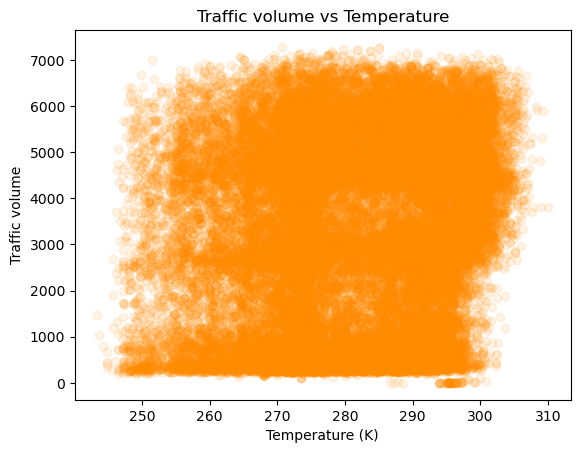

In [14]:
# Traffic volume vs Temperature
plt.scatter(traffic.temp, traffic.traffic_volume, color='darkorange', alpha=0.1)
plt.title('Traffic volume vs Temperature')

plt.xlabel('Temperature (K)')
plt.ylabel('Traffic volume')

plt.show()

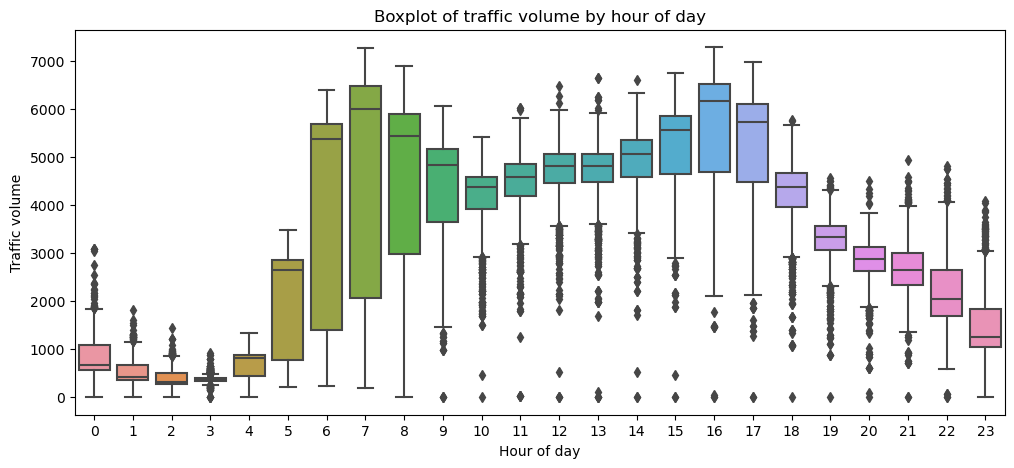

In [50]:
# Average traffic volume by hour of day
plt.figure(figsize=(12, 5))
sns.boxplot(x='hour', y='traffic_volume', data=traffic)

plt.title('Boxplot of traffic volume by hour of day')
plt.xlabel('Hour of day')
plt.ylabel('Traffic volume')

plt.show()

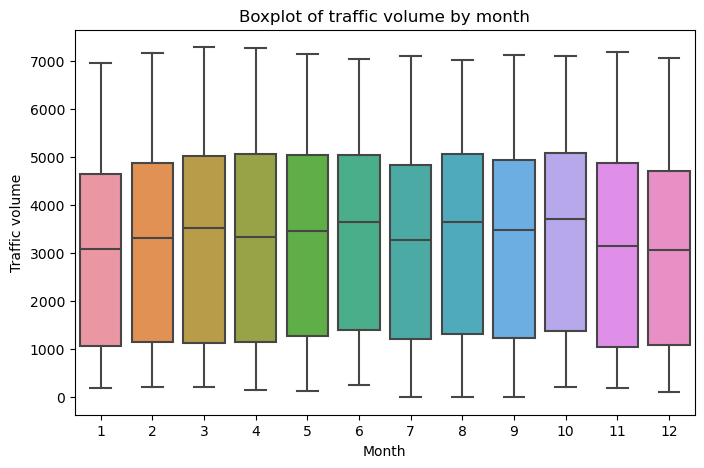

In [51]:
# Average traffic volume by months of the year
plt.figure(figsize=(8, 5))
sns.boxplot(x='month', y='traffic_volume', data=traffic)

plt.title('Boxplot of traffic volume by month')
plt.xlabel('Month')
plt.ylabel('Traffic volume')

plt.show()

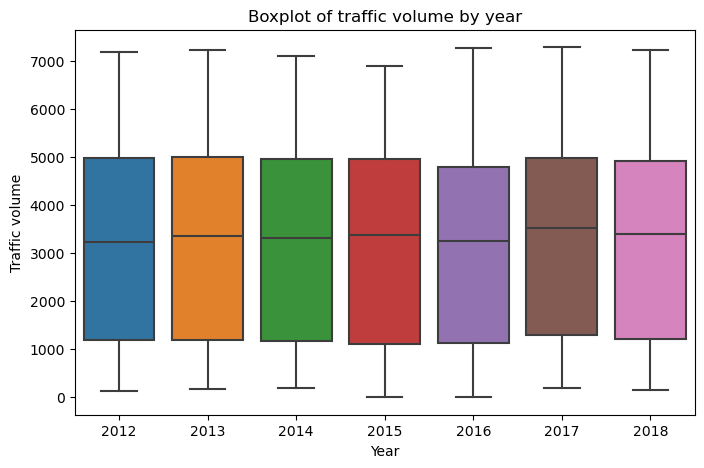

In [14]:
# Average traffic volume by year
plt.figure(figsize=(8, 5))
sns.boxplot(x='year', y='traffic_volume', data=traffic)

plt.title('Boxplot of traffic volume by year')
plt.xlabel('Year')
plt.ylabel('Traffic volume')

plt.show()

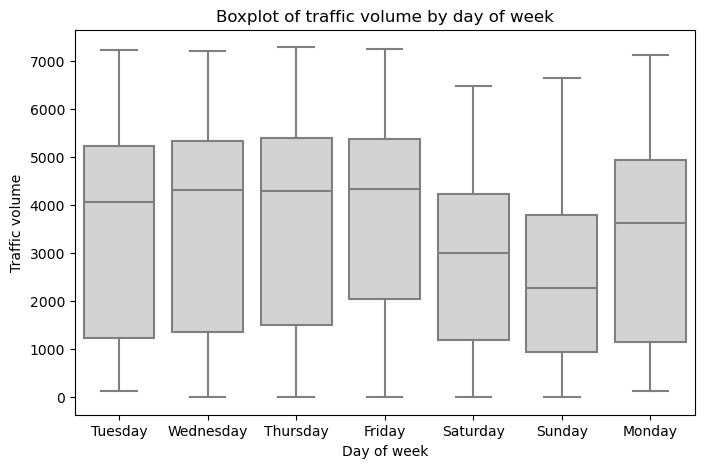

In [52]:
# Average traffic volume by day of the week
plt.figure(figsize=(8, 5))
sns.boxplot(x='day_of_week', y='traffic_volume', data=traffic, color='lightgrey')

plt.title('Boxplot of traffic volume by day of week')
plt.xlabel('Day of week')
plt.ylabel('Traffic volume')

plt.show()

In summary:
- Expect low correlation from temperature and month of the year.
- Hours massively impact traffic volume, with traffic peaking at rush hours.
- Traffic considerably decreases during weekends, as expected.
- There are no increasing nor decreasing trends per year in this dataset.

# 3.4 Modeling and Evaluation (``traffic``)
To put simply, from the data exploration step, we'll fit values of:
- Qualitative: Hour of day (24), Day of the week (7), Holidays (11), and Weather description (11 or 38)
- Quantitative: Temperature

Rainfall, Snowfall, and Cloud coverage are not used in this case due to redundancy with descriptions of weather.

## Create dataframes appropriate for regression (no weather, main description, detailed description)

In [24]:
# Dataframe for no weather conditions considered in model
X_none = pd.concat([traffic.temp, dummy_hour, dummy_dayOfWeek, dummy_holiday],
                   axis=1)
y_none = traffic.traffic_volume

X_none.head()

,temp,hr0,hr1,hr2,hr3,hr4,hr5,hr6,hr7,hr8,...,Columbus Day,Independence Day,Labor Day,Martin Luther King Jr Day,Memorial Day,New Years Day,State Fair,Thanksgiving Day,Veterans Day,Washingtons Birthday
0,288.28,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,289.36,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,289.58,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,290.13,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,291.14,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [40]:
# Dataframe for main weather conditions considered in model
X_main = pd.concat([traffic.temp, dummy_hour, dummy_dayOfWeek, dummy_holiday, dummy_weaMain],
                   axis=1)
y_main = traffic.traffic_volume

X_main.head()

,temp,hr0,hr1,hr2,hr3,hr4,hr5,hr6,hr7,hr8,...,Clouds,Drizzle,Fog,Haze,Mist,Rain,Smoke,Snow,Squall,Thunderstorm
0,288.28,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
1,289.36,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2,289.58,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
3,290.13,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,291.14,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False


In [26]:
# Dataframe for detailed weather descriptions considered in model
X_desc = pd.concat([traffic.temp, dummy_hour, dummy_dayOfWeek, dummy_holiday, dummy_weaDesc],
                   axis=1)
y_desc = traffic.traffic_volume

X_desc.head()

,temp,hr0,hr1,hr2,hr3,hr4,hr5,hr6,hr7,hr8,...,sleet,smoke,snow,thunderstorm,thunderstorm with drizzle,thunderstorm with heavy rain,thunderstorm with light drizzle,thunderstorm with light rain,thunderstorm with rain,very heavy rain
0,288.28,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,289.36,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,289.58,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,290.13,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,291.14,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [42]:
# Array for "bad weather" (NOT "Clear" AND NOT "Clouds") booleans in array
bad_weather = (traffic.weather_main != 'Clear') & (traffic.weather_main != 'Clouds')

bad_weather.head()

0    False
1    False
2    False
3    False
4    False
Name: weather_main, dtype: bool

## Select regression models
We'll use linear regression, decision tree, random forest, bagging and XGBoost regression for the models.

The test data used will be the traffic volume data from the last 30% rows, in order to simulate future traffic prediction and not do traffic volume interpolation.

Finally, "Bad weather RMSE" is RMSE from predicted data with "bad weather," defined to be data without "Clear" or "Clouds" weather in the weather_main column of traffic dataframe.

In [44]:
# List of models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest' : RandomForestRegressor(),
    'Bagging': BaggingRegressor(),
    'xGBoost': XGBRegressor(),
}

## Apply models and report (no weather)

In [52]:
# Empty lists 
model_used = []
r2 = []
RMSE_train = []
RMSE_test = []
RMSE_bad_weather = []

# Split into training and test data
rows = int(len(X_none.index) * 3/10)

X_train = X_none[:-rows]
X_test = X_none[-rows:]

y_train = y_none[:-rows]
y_test = y_none[-rows:]

bad_weather_test = bad_weather[-rows:]

# Evaluate models
for name, model in models.items():
    # Training
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Results
    model_r2 = r2_score(y_test, y_test_pred)
    model_rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    model_rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    # Results (Bad weather)
    y_bad_weather = y_test[bad_weather_test]
    y_bad_weather_pred = y_test_pred[bad_weather_test]
    model_rmse_bad_weather = np.sqrt(mean_squared_error(y_bad_weather, y_bad_weather_pred))
    
    # Append to lists
    model_used.append(name)
    r2.append(model_r2)
    RMSE_train.append(model_rmse_train)
    RMSE_test.append(model_rmse_test)
    RMSE_bad_weather.append(model_rmse_bad_weather)

    # Results report
    print(f'--------- Results for model: {name} ---------')
    print(f'Test R2 score: {model_r2}')
    print(f'Train RMSE: {model_rmse_train}')
    print(f'Test RMSE: {model_rmse_test}')
    print(f'Bad Weather RMSE: {model_rmse_bad_weather}')
    print()

--------- Results for model: Linear Regression ---------
Test R2 score: 0.832301932398759
Train RMSE: 823.1043747687768
Test RMSE: 808.8207887635139
Bad Weather RMSE: 857.5569461935241

--------- Results for model: Decision Tree ---------
Test R2 score: 0.881813646720483
Train RMSE: 77.94922969253
Test RMSE: 679.0033896031273
Bad Weather RMSE: 713.9136640996201

--------- Results for model: Random Forest ---------
Test R2 score: 0.9174658385866319
Train RMSE: 201.2954291062415
Test RMSE: 567.4206639493927
Bad Weather RMSE: 599.5933032140672

--------- Results for model: Bagging ---------
Test R2 score: 0.9157449942660285
Train RMSE: 226.28886314584366
Test RMSE: 573.3055318718099
Bad Weather RMSE: 605.0511613444986

--------- Results for model: xGBoost ---------
Test R2 score: 0.9362441653874394
Train RMSE: 440.4728133228215
Test RMSE: 498.7101919008958
Bad Weather RMSE: 543.9349740463786



In [53]:
# Create dataframe for this result and save to csv
no_weather_results = {
    'model': model_used,
    'r2': r2,
    'train_rmse': RMSE_train,
    'test_rmse': RMSE_test,
    'bad_weather_rmse': RMSE_bad_weather
}

no_weather_results = pd.DataFrame(no_weather_results)
no_weather_results.to_csv('results_weather_none.csv', index=False)

print(no_weather_results)

               model        r2  train_rmse   test_rmse  bad_weather_rmse
0  Linear Regression  0.832302  823.104375  808.820789        857.556946
1      Decision Tree  0.881814   77.949230  679.003390        713.913664
2      Random Forest  0.917466  201.295429  567.420664        599.593303
3            Bagging  0.915745  226.288863  573.305532        605.051161
4            xGBoost  0.936244  440.472813  498.710192        543.934974


## Apply models and report (weather_main)

In [54]:
# Empty lists 
model_used = []
r2 = []
RMSE_train = []
RMSE_test = []
RMSE_bad_weather = []

# Split into training and test data
rows = int(len(X_main.index) * 3/10)

X_train = X_main[:-rows]
X_test = X_main[-rows:]

y_train = y_main[:-rows]
y_test = y_main[-rows:]

bad_weather_test = bad_weather[-rows:]

# Evaluate models
for name, model in models.items():
    # Training
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Results
    model_r2 = r2_score(y_test, y_test_pred)
    model_rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    model_rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    # Results (Bad weather)
    y_bad_weather = y_test[bad_weather_test]
    y_bad_weather_pred = y_test_pred[bad_weather_test]
    model_rmse_bad_weather = np.sqrt(mean_squared_error(y_bad_weather, y_bad_weather_pred))
    
    # Append to lists
    model_used.append(name)
    r2.append(model_r2)
    RMSE_train.append(model_rmse_train)
    RMSE_test.append(model_rmse_test)
    RMSE_bad_weather.append(model_rmse_bad_weather)

    # Results report
    print(f'--------- Results for model: {name} ---------')
    print(f'Test R2 score: {model_r2}')
    print(f'Train RMSE: {model_rmse_train}')
    print(f'Test RMSE: {model_rmse_test}')
    print(f'Bad Weather RMSE: {model_rmse_bad_weather}')
    print()

--------- Results for model: Linear Regression ---------
Test R2 score: 0.833687975362988
Train RMSE: 821.0703829142789
Test RMSE: 805.4713571811429
Bad Weather RMSE: 853.7790127064674

--------- Results for model: Decision Tree ---------
Test R2 score: 0.8805152884818044
Train RMSE: 38.56221459789601
Test RMSE: 682.7228614898702
Bad Weather RMSE: 740.8608553089668

--------- Results for model: Random Forest ---------
Test R2 score: 0.9269068808236638
Train RMSE: 196.33774389866997
Test RMSE: 533.9818845889255
Bad Weather RMSE: 575.1272633721178

--------- Results for model: Bagging ---------
Test R2 score: 0.9224676601043682
Train RMSE: 224.46760502410922
Test RMSE: 549.9582503197915
Bad Weather RMSE: 599.8413861639732

--------- Results for model: xGBoost ---------
Test R2 score: 0.9395730544182934
Train RMSE: 428.38803835693597
Test RMSE: 485.5160567885917
Bad Weather RMSE: 532.327224363458



In [55]:
# Create dataframe for this result and save to csv
weather_main_results = {
    'model': model_used,
    'r2': r2,
    'train_rmse': RMSE_train,
    'test_rmse': RMSE_test,
    'bad_weather_rmse': RMSE_bad_weather
}

weather_main_results = pd.DataFrame(weather_main_results)
weather_main_results.to_csv('results_weather_main.csv', index=False)

print(weather_main_results)

               model        r2  train_rmse   test_rmse  bad_weather_rmse
0  Linear Regression  0.833688  821.070383  805.471357        853.779013
1      Decision Tree  0.880515   38.562215  682.722861        740.860855
2      Random Forest  0.926907  196.337744  533.981885        575.127263
3            Bagging  0.922468  224.467605  549.958250        599.841386
4            xGBoost  0.939573  428.388038  485.516057        532.327224


## Apply models and report (weather_descriptions)

In [60]:
# Empty lists 
model_used = []
r2 = []
RMSE_train = []
RMSE_test = []
RMSE_bad_weather = []

# Split into training and test data
rows = int(len(X_desc.index) * 3/10)

X_train = X_desc[:-rows]
X_test = X_desc[-rows:]

y_train = y_desc[:-rows]
y_test = y_desc[-rows:]

bad_weather_test = bad_weather[-rows:]

# Evaluate models
for name, model in models.items():
    # Training
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Results
    model_r2 = r2_score(y_test, y_test_pred)
    model_rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    model_rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    # Results (Bad weather)
    y_bad_weather = y_test[bad_weather_test]
    y_bad_weather_pred = y_test_pred[bad_weather_test]
    model_rmse_bad_weather = np.sqrt(mean_squared_error(y_bad_weather, y_bad_weather_pred))
    
    # Append to lists
    model_used.append(name)
    r2.append(model_r2)
    RMSE_train.append(model_rmse_train)
    RMSE_test.append(model_rmse_test)
    RMSE_bad_weather.append(model_rmse_bad_weather)

    # Results report
    print(f'--------- Results for model: {name} ---------')
    print(f'Test R2 score: {model_r2}')
    print(f'Train RMSE: {model_rmse_train}')
    print(f'Test RMSE: {model_rmse_test}')
    print(f'Bad Weather RMSE: {model_rmse_bad_weather}')
    print()

--------- Results for model: Linear Regression ---------
Test R2 score: 0.8333333666912951
Train RMSE: 819.8443251301878
Test RMSE: 806.3296085253361
Bad Weather RMSE: 854.8780033999396

--------- Results for model: Decision Tree ---------
Test R2 score: 0.8815890397405657
Train RMSE: 26.564765500589175
Test RMSE: 679.6482885548105
Bad Weather RMSE: 705.8108929272792

--------- Results for model: Random Forest ---------
Test R2 score: 0.927358732152173
Train RMSE: 195.2726375603451
Test RMSE: 532.3288256273459
Bad Weather RMSE: 570.4860503762562

--------- Results for model: Bagging ---------
Test R2 score: 0.9225110146901991
Train RMSE: 223.98197755414722
Test RMSE: 549.8044658067929
Bad Weather RMSE: 591.4201531202336

--------- Results for model: xGBoost ---------
Test R2 score: 0.9408150389075106
Train RMSE: 434.80651851142625
Test RMSE: 480.5006276713736
Bad Weather RMSE: 520.7186526603849



In [61]:
# Create dataframe for this result and save to csv
weather_desc_results = {
    'model': model_used,
    'r2': r2,
    'train_rmse': RMSE_train,
    'test_rmse': RMSE_test,
    'bad_weather_rmse': RMSE_bad_weather
}

weather_desc_results = pd.DataFrame(weather_desc_results)
weather_desc_results.to_csv('results_weather_desc.csv', index=False)

print(weather_desc_results)

               model        r2  train_rmse   test_rmse  bad_weather_rmse
0  Linear Regression  0.833333  819.844325  806.329609        854.878003
1      Decision Tree  0.881589   26.564766  679.648289        705.810893
2      Random Forest  0.927359  195.272638  532.328826        570.486050
3            Bagging  0.922511  223.981978  549.804466        591.420153
4            xGBoost  0.940815  434.806519  480.500628        520.718653


# 4.1 Data cleaning and Feature Engineering (``ERA5``)

## Legend

The column name information could be found on https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=overview, where:
- **t2m:** 2m temperature
- **tcc:** Total cloud cover (0-1)
- **lcc:** Low cloud cover (0-1)
- **mcc:** Medium cloud cover (0-1)
- **hcc:** High cloud cover (0-1)
- **valid_time/date_time:** Specified time
- **ptype:** Precipitation type at surface
- **tp:** Total precipitation, rain and snow, in meters
- **sf:** Snowfall, in meters
- **cp:** Convective precipitation, in meters
- **lsp:** Large-scale precipitation, in meters
- All values in meters will be converted to millimeters during the data cleaning process

## Check NULL values

In [14]:
print('NULL value count')
print(ERA5.isnull().sum())
print()

print(f'Duplicate count: {ERA5.duplicated().sum()}')
print()

print('INF value count')
print(ERA5.isin([np.inf]).sum(axis=0))

NULL value count
t2m           0
tcc           0
lcc           0
mcc           0
hcc           0
valid_time    0
ptype         0
tp            0
sf            0
cp            0
lsp           0
dtype: int64

Duplicate count: 0

INF value count
t2m           0
tcc           0
lcc           0
mcc           0
hcc           0
valid_time    0
ptype         0
tp            0
sf            0
cp            0
lsp           0
dtype: int64


## Change values to appropriate formats

In [15]:
# Convert datetime to appropriate format and rename column
ERA5.valid_time = pd.to_datetime(ERA5.valid_time, yearfirst=True)
ERA5.rename(columns={'valid_time': 'date_time'}, inplace=True)

# Rename integer assignments to corresponding categorical values
ERA5.ptype = ERA5.ptype.replace({0: 'None', 
                               1: 'Rain',
                               3: 'Freezing rain',
                               5: 'Snow',
                               6: 'Wet snow',
                               7: 'Rain-snow mix',
                               8: 'Ice pellets'
                              })

# Convert precipitation data from m to mm
ERA5[['tp', 'sf', 'cp', 'lsp']] *= 1000

# Convert to appropriate timezone from UTC to CST (UTC-06:00)
ERA5.date_time = ERA5.date_time - pd.Timedelta(hours=6)

ERA5.head()

,t2m,tcc,lcc,mcc,hcc,date_time,ptype,tp,sf,cp,lsp
0,275.64478,0.945885,0.349785,0.220996,0.924800,2011-12-31 18:00:00,Ice pellets,0.000000,0.000000,0.000000,0.000000
1,274.96802,0.992929,0.787845,0.821806,0.972085,2011-12-31 19:00:00,Rain,0.076868,0.000000,0.069830,0.007533
2,275.06910,1.000000,0.882888,0.981989,0.974361,2011-12-31 20:00:00,Rain,0.099305,0.000000,0.039909,0.059568
3,273.99487,0.999468,0.689093,0.996290,0.954493,2011-12-31 21:00:00,Rain-snow mix,0.410839,0.048706,0.117827,0.292860
4,274.07740,1.000000,0.914553,1.000000,0.993137,2011-12-31 22:00:00,Wet snow,1.072464,0.808361,0.219008,0.853409


## Discard all dates that does not exist in traffic dataset

In [16]:
print(f'ERA5 row count (before): {len(ERA5)}')

ERA5 = pd.merge(traffic.date_time, ERA5, on='date_time', how='inner')

print(f'ERA5 row count (after): {len(ERA5)}')

ERA5.head()

ERA5 row count (before): 61368
ERA5 row count (after): 48176


,date_time,t2m,tcc,lcc,mcc,hcc,ptype,tp,sf,cp,lsp
0,2012-10-02 09:00:00,288.61840,0.000000,0.0,0.0,0.000000,None,0.0,0.0,0.0,0.0
1,2012-10-02 10:00:00,290.27368,0.020929,0.0,0.0,0.020929,None,0.0,0.0,0.0,0.0
2,2012-10-02 11:00:00,291.98755,0.000000,0.0,0.0,0.000000,None,0.0,0.0,0.0,0.0
3,2012-10-02 12:00:00,292.57960,0.000000,0.0,0.0,0.000000,None,0.0,0.0,0.0,0.0
4,2012-10-02 13:00:00,293.49878,0.000000,0.0,0.0,0.000000,None,0.0,0.0,0.0,0.0


# 4.2 Data exploration (``ERA5``)

## Check distributions of data

In [17]:
# Check precipitation type distribution
ERA5.ptype.value_counts()

ptype
None             27179
Rain             11070
Snow              8280
Wet snow          1283
Rain-snow mix      246
Ice pellets         67
Freezing rain       51
Name: count, dtype: int64

In [19]:
# Check percentage of weather types with total precipitation going over 0.1 mm
ERA5[ERA5.tp > 0.1].ptype.value_counts() / ERA5.ptype.value_counts() * 100

ptype
Freezing rain    45.098039
Ice pellets      28.358209
None              1.729276
Rain             50.885276
Rain-snow mix    73.983740
Snow             22.173913
Wet snow         40.218239
Name: count, dtype: float64

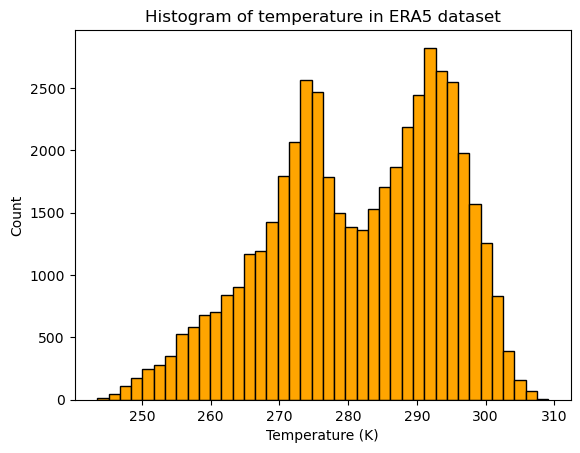

In [20]:
# Tempearature distribution
plt.title("Histogram of temperature in ERA5 dataset")

plt.xlabel("Temperature (K)")
plt.ylabel("Count")

plt.hist(ERA5.t2m, color='orange', ec='black', bins=40)

plt.show()

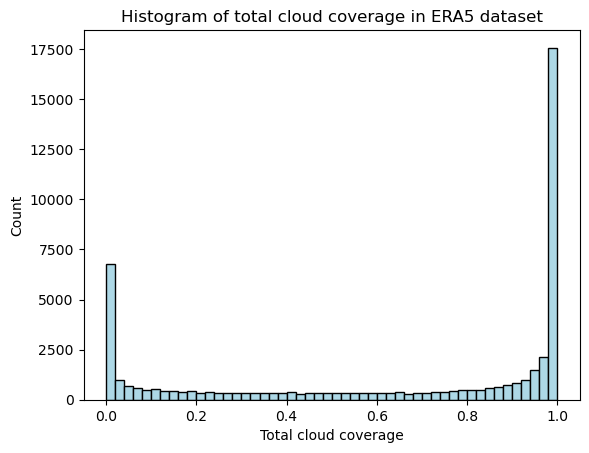

In [21]:
# Cloud coverage distribution
plt.title("Histogram of total cloud coverage in ERA5 dataset")

plt.xlabel("Total cloud coverage")
plt.ylabel("Count")

plt.hist(ERA5.tcc, color='lightblue', ec='black', bins=50)

plt.show()

## Check distributions of data by precipitation type

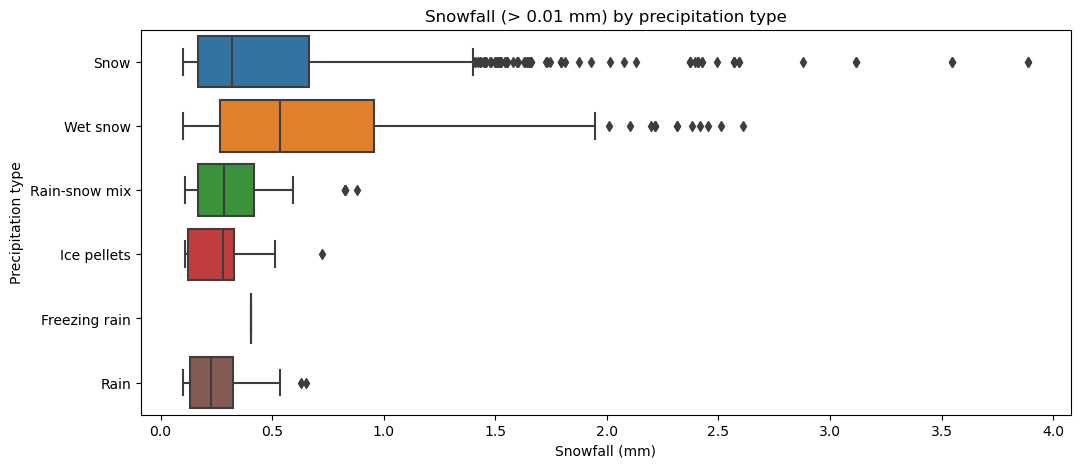

In [22]:
# Snowfall (> 0.01 mm) by precipitation type
plt.figure(figsize=(12, 5))
sns.boxplot(x='sf', y='ptype', data=ERA5[ERA5.sf > 0.1])

plt.title('Snowfall (> 0.01 mm) by precipitation type')
plt.xlabel('Snowfall (mm)')
plt.ylabel('Precipitation type')

plt.show()

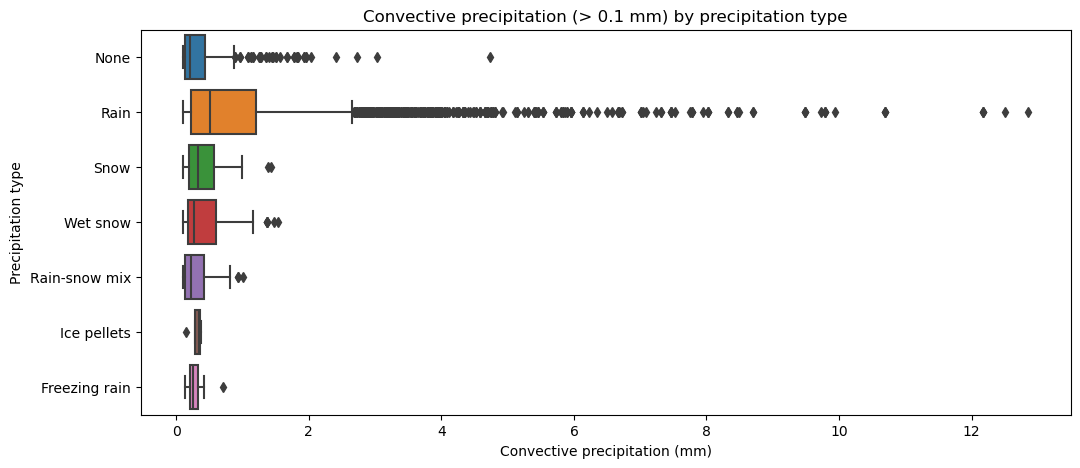

In [23]:
# Convective precipitation (> 0.01 mm) by precipitation type
plt.figure(figsize=(12, 5))
sns.boxplot(x='cp', y='ptype', data=ERA5[ERA5.cp > 0.1])

plt.title('Convective precipitation (> 0.1 mm) by precipitation type')
plt.xlabel('Convective precipitation (mm)')
plt.ylabel('Precipitation type')

plt.show()

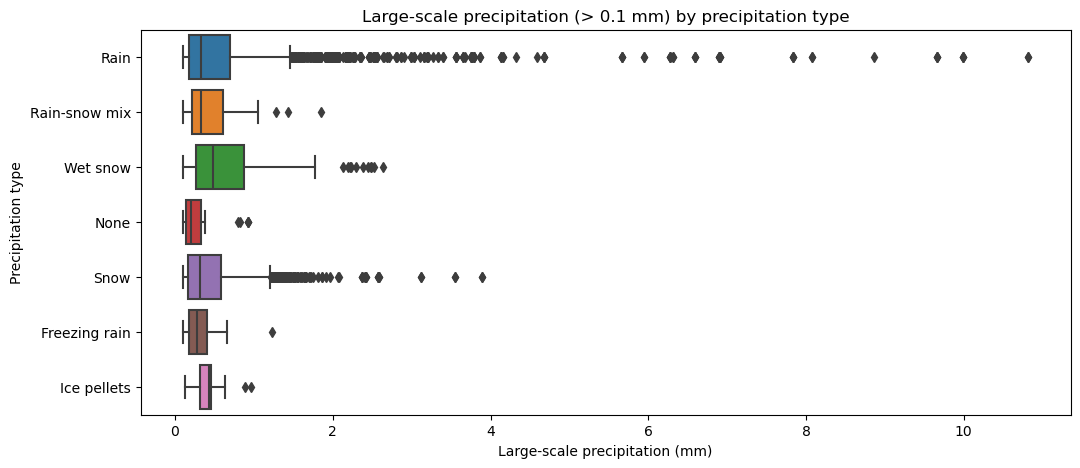

In [24]:
# Large-scale precipitation (> 0.1 mm) by precipitation type
plt.figure(figsize=(12, 5))
sns.boxplot(x='lsp', y='ptype', data=ERA5[ERA5.lsp > 0.1])

plt.title('Large-scale precipitation (> 0.1 mm) by precipitation type')
plt.xlabel('Large-scale precipitation (mm)')
plt.ylabel('Precipitation type')

plt.show()

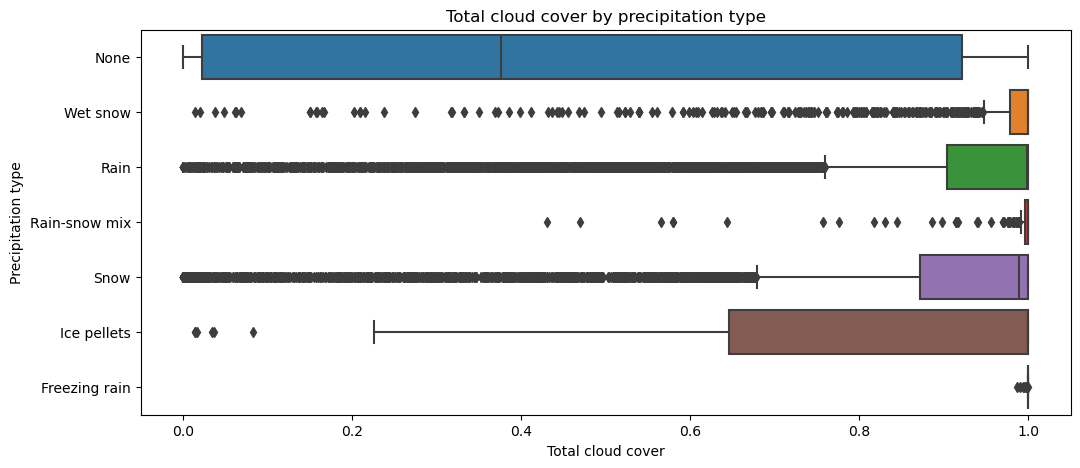

In [25]:
# Cloud cover by precipitation type
plt.figure(figsize=(12, 5))
sns.boxplot(x='tcc', y='ptype', data=ERA5)

plt.title('Total cloud cover by precipitation type')
plt.xlabel('Total cloud cover')
plt.ylabel('Precipitation type')

plt.show()

## Check relationships between measured and ERA5 values (Numerical)

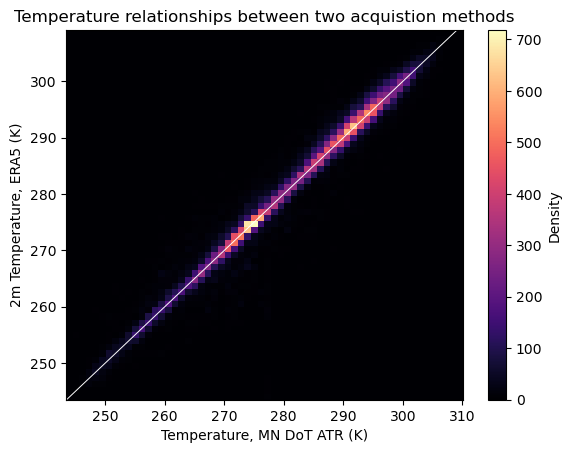

In [26]:
# Correlations between temperatures
plt.hist2d(traffic.temp, ERA5.t2m, bins=60, cmap="magma")

# Creates straight line y = x for reference
straight_line = np.linspace(240, 310, 5)
plt.plot(straight_line, straight_line, color="white", linewidth=0.7)

plt.title('Temperature relationships between two acquistion methods')
plt.colorbar(label="Density")

plt.xlabel('Temperature, MN DoT ATR (K)')
plt.ylabel('2m Temperature, ERA5 (K)')

plt.show()

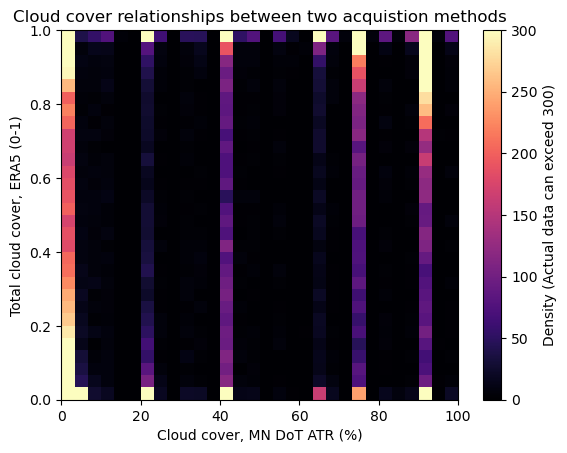

In [27]:
# Correlations between cloud coverage
plt.hist2d(traffic.clouds_all, ERA5.tcc, bins=30, vmin=0, vmax=300, cmap="magma")

plt.title('Cloud cover relationships between two acquistion methods')
plt.colorbar(label="Density (Actual data can exceed 300)")

plt.xlabel('Cloud cover, MN DoT ATR (%)')
plt.ylabel('Total cloud cover, ERA5 (0-1)')

plt.show()

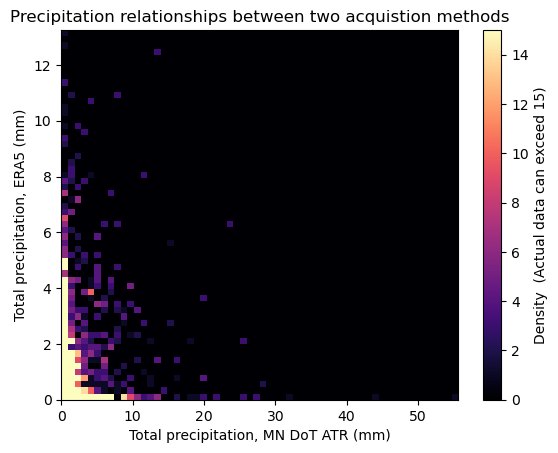

In [58]:
# Correlations between precipitation
plt.hist2d(traffic.rain_1h + traffic.snow_1h, ERA5.tp, bins=60, vmin=0, vmax=15, cmap="magma")

plt.title('Precipitation relationships between two acquistion methods')
plt.colorbar(label="Density  (Actual data can exceed 15)")

plt.xlabel('Total precipitation, MN DoT ATR (mm)')
plt.ylabel('Total precipitation, ERA5 (mm)')

plt.show()

## Check relationships between measured and ERA5 values (Categorical)

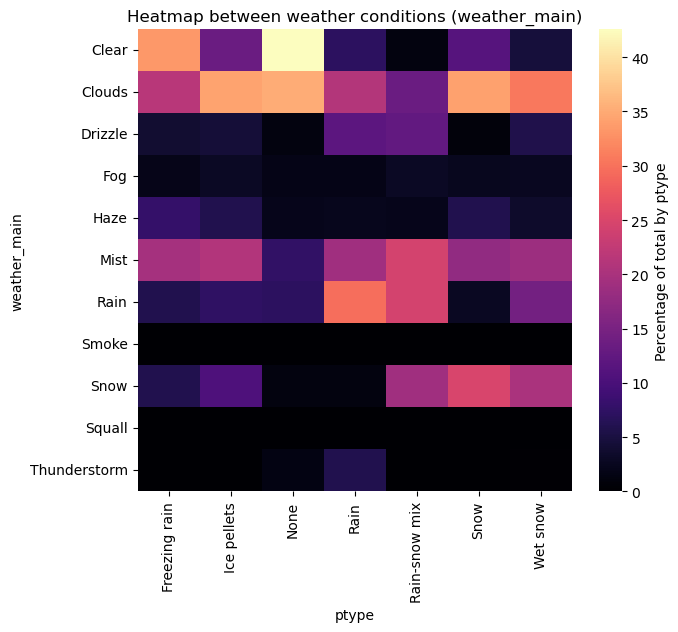

In [29]:
# Heatmap between precipitation types (weather_main)
count_matrix = pd.crosstab(traffic.weather_main, ERA5.ptype)
count_matrix = count_matrix.div(count_matrix.sum(), axis=1) * 100 # Converts values to percentage over ptype

plt.figure(figsize=(7, 6)) 
sns.heatmap(count_matrix, cmap="magma", cbar_kws={'label': 'Percentage of total by ptype'})

plt.title("Heatmap between weather conditions (weather_main)")
plt.show()

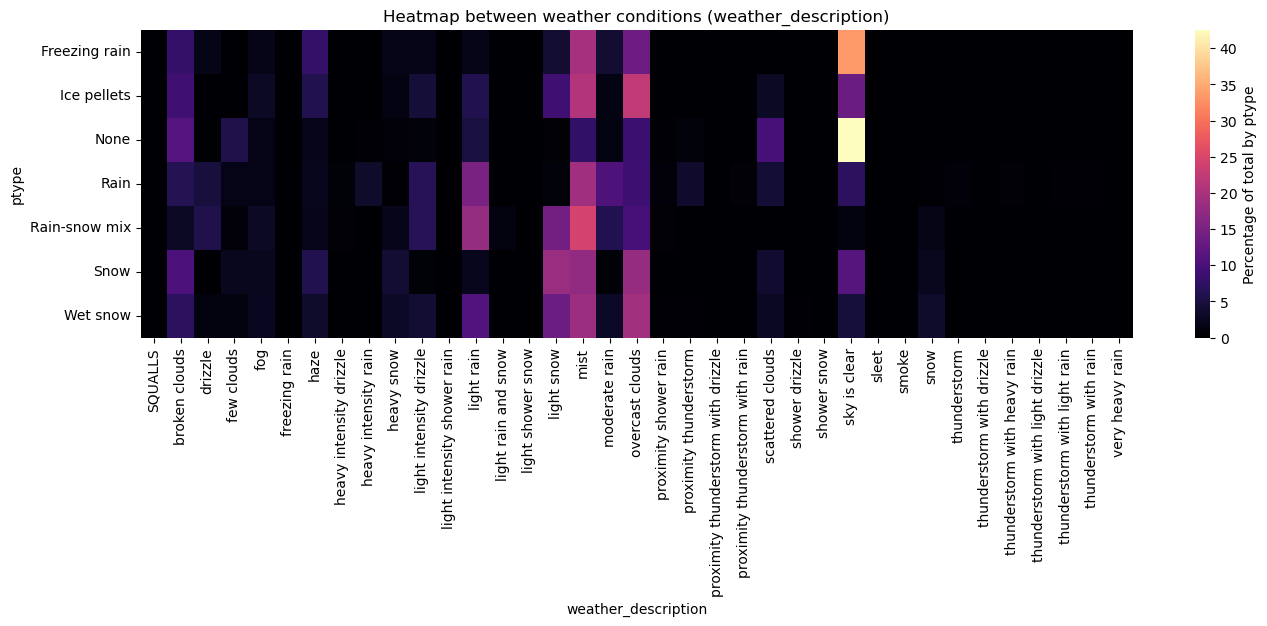

In [30]:
# Heatmap between precipitation types (weather_description)
count_matrix = pd.crosstab(traffic.weather_description, ERA5.ptype)
count_matrix = (count_matrix.div(count_matrix.sum(), axis=1) * 100).transpose() # Converts values to percentage over ptype

plt.figure(figsize=(16, 4))
sns.heatmap(count_matrix, cmap="magma", cbar_kws={'label': 'Percentage of total by ptype'})
plt.title("Heatmap between weather conditions (weather_description)")
plt.show()

## Check relationships between traffic volume and ERA5 values

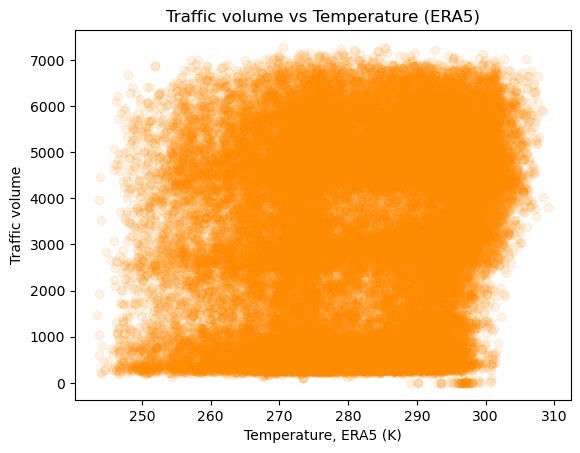

In [31]:
# Traffic volume vs Temperature
plt.scatter(ERA5.t2m, traffic.traffic_volume, color='darkorange', alpha=0.1)
plt.title('Traffic volume vs Temperature (ERA5)')

plt.xlabel('Temperature, ERA5 (K)')
plt.ylabel('Traffic volume')

plt.show()

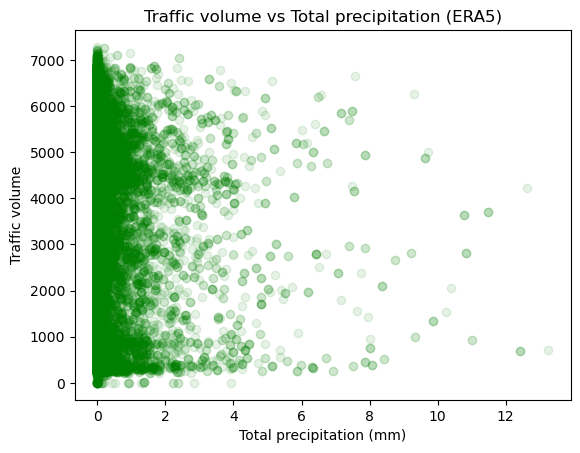

In [32]:
# Traffic volume vs Total precipitation
plt.scatter(ERA5.tp, traffic.traffic_volume, color='green', alpha=0.1)
plt.title('Traffic volume vs Total precipitation (ERA5)')

plt.xlabel('Total precipitation (mm)')
plt.ylabel('Traffic volume')

plt.show()

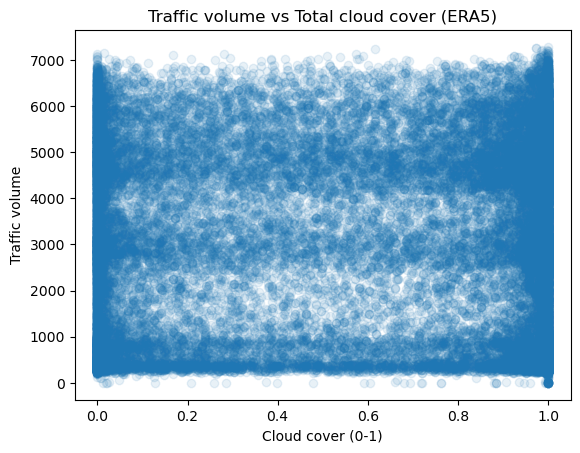

In [33]:
# Traffic volume vs Cloud coverage
plt.scatter(ERA5.tcc, traffic.traffic_volume, alpha=0.1)
plt.title('Traffic volume vs Total cloud cover (ERA5)')

plt.xlabel('Cloud cover (0-1)')
plt.ylabel('Traffic volume')

plt.show()

In [34]:
# List indicating if total precipitation exceeds 0.1 mm or not
precipitation_threshold = pd.Series((ERA5.tp > 0.1).tolist())
precipitation_threshold = precipitation_threshold.replace({False: '<= 0.1 mm',
                                                          True: '> 0.1 mm'})
precipitation_threshold.name = 'condition'

print(precipitation_threshold)

0        <= 0.1 mm
1        <= 0.1 mm
2        <= 0.1 mm
3        <= 0.1 mm
4        <= 0.1 mm
           ...    
48171     > 0.1 mm
48172    <= 0.1 mm
48173    <= 0.1 mm
48174    <= 0.1 mm
48175    <= 0.1 mm
Name: condition, Length: 48176, dtype: object


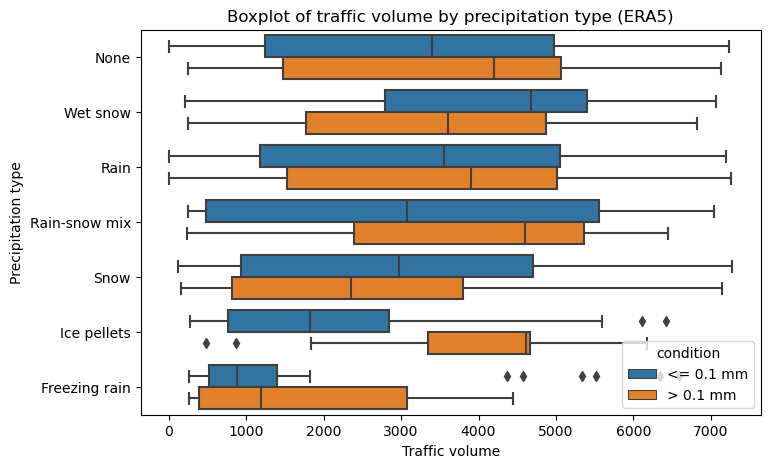

In [35]:
# Average traffic volume by precipitation type
plt.figure(figsize=(8, 5))
sns.boxplot(x='traffic_volume', y='ptype', hue='condition',
            data=pd.DataFrame([ERA5.ptype, 
                               traffic.traffic_volume,
                               precipitation_threshold]).transpose()
           )

plt.title('Boxplot of traffic volume by precipitation type (ERA5)')

plt.xlabel('Traffic volume')
plt.ylabel('Precipitation type')

plt.show()

## Time series between datasets

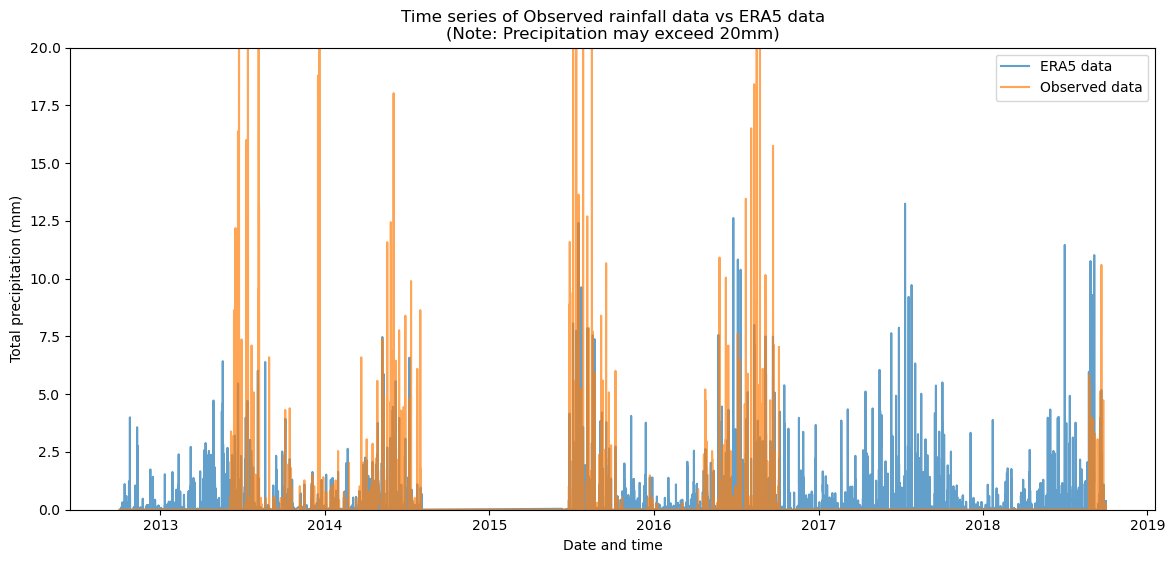

In [36]:
# Time series between observed precipiration and ERA5 precipitation
plt.figure(figsize=(14, 6))

plt.plot(ERA5.date_time, ERA5.tp, label='ERA5 data', alpha=0.7)
plt.plot(traffic.date_time, traffic.rain_1h + traffic.snow_1h, label='Observed data', alpha=0.7)

plt.title('Time series of Observed rainfall data vs ERA5 data\n(Note: Precipitation may exceed 20mm)')

plt.xlabel('Date and time')
plt.ylabel('Total precipitation (mm)')

plt.legend()
plt.ylim(0,20)

plt.show()

## Conclusions

From the extensive data exploration process above, we now know that:
- There exists a great correlation between ERA5 and observed data in terms of temperature, confirming that the datasets are at the very least, at the same general vicinity.
- There exists no apparent correlation between ERA5 and observed data in terms of cloud coverage and precipitation. This is likely due to multiple factors:
- 1. Precipitation data being "missing" in the observed data as seen from the time series
- 2. ERA5 data being a gridded average obtained from modeling rather than data observed in a single point
- 3. Either or both of the two data being unreliable in the first place.
- Weather descriptions are somewhat related. Most of the "None" ptype values of the ERA5 data aggregate at "Clear" or "Cloudy" weather, for instance.
- Interestingly, despite seeing little-to-no correlation between precipitation and traffic volume when directly plotting them against each other, if we were to partition the precipitation type by a precipitation threshold, one can see the stark difference between traffic volumes in a box plot.

# 4.3 Modeling and Evaluation (``ERA5``)
From this, we'll fit values of
- Qualitative: Hour of day (traffic), Day of the week (traffic), Holidays (traffic), and Weather description (ERA5, separated by precipitation threshold of 0.1 mm)
- Quantitative: Temperature (ERA5)

Just like the above cases, we'll use linear regression, decision tree, random forest, bagging and XGBoost regression for the models, and the test data will be the traffic volume data from the last 30% rows.

The 0.1mm threshold is picked as it is roughly the order of magnitude that separates the "lighter" precipirations and "heavier" precipitations respectively with reasonable proportions (see data exploration/check distributions of data). In other words, it's a hyperparameter.

Note that bad_weather conditions will still follow the same conditions as the traffic dataframe, even if the ERA5 data says otherwise. This is for consistency.

## One hot encoding for precipitation type, separated by total precipitation threshold

In [37]:
# Create temporary dataframe that includes precipitation threshold
threshold = 0.1

dummy_weaERA5 = ERA5[['ptype', 'tp']]

dummy_weaERA5.ptype = dummy_weaERA5.apply(
    lambda row: row.ptype + '_light' if row['tp'] > threshold
    else row['ptype'] + '_heavy',
    axis=1
)

# Final one hot encoding
dummy_weaERA5 = pd.get_dummies(dummy_weaERA5.ptype)
dummy_weaERA5.head()

C:\Users\WBS\AppData\Local\Temp\ipykernel_712\3108640782.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dummy_weaERA5.ptype = dummy_weaERA5.apply(


,Freezing rain_heavy,Freezing rain_light,Ice pellets_heavy,Ice pellets_light,None_heavy,None_light,Rain-snow mix_heavy,Rain-snow mix_light,Rain_heavy,Rain_light,Snow_heavy,Snow_light,Wet snow_heavy,Wet snow_light
0,False,False,False,False,True,False,False,False,False,False,False,False,False,False
1,False,False,False,False,True,False,False,False,False,False,False,False,False,False
2,False,False,False,False,True,False,False,False,False,False,False,False,False,False
3,False,False,False,False,True,False,False,False,False,False,False,False,False,False
4,False,False,False,False,True,False,False,False,False,False,False,False,False,False


## Apply models and report

In [38]:
# Create dataframe appropriate for training
X_ERA5 = pd.concat([traffic.temp, dummy_hour, dummy_dayOfWeek, dummy_holiday, dummy_weaERA5],
                   axis=1)
y_ERA5 = traffic.traffic_volume

X_ERA5.head()

,temp,hr0,hr1,hr2,hr3,hr4,hr5,hr6,hr7,hr8,...,None_heavy,None_light,Rain-snow mix_heavy,Rain-snow mix_light,Rain_heavy,Rain_light,Snow_heavy,Snow_light,Wet snow_heavy,Wet snow_light
0,288.28,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
1,289.36,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2,289.58,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
3,290.13,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,291.14,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False


In [45]:
# Empty lists 
model_used = []
r2 = []
RMSE_train = []
RMSE_test = []
RMSE_bad_weather = []

# Split into training and test data
rows = int(len(X_main.index) * 3/10)

X_train = X_ERA5[:-rows]
X_test = X_ERA5[-rows:]

y_train = y_ERA5[:-rows]
y_test = y_ERA5[-rows:]

bad_weather_test = bad_weather[-rows:]

# Evaluate models
for name, model in models.items():
    # Training
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Results
    model_r2 = r2_score(y_test, y_test_pred)
    model_rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    model_rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    # Results (Bad weather)
    y_bad_weather = y_test[bad_weather_test]
    y_bad_weather_pred = y_test_pred[bad_weather_test]
    model_rmse_bad_weather = np.sqrt(mean_squared_error(y_bad_weather, y_bad_weather_pred))
    
    # Append to lists
    model_used.append(name)
    r2.append(model_r2)
    RMSE_train.append(model_rmse_train)
    RMSE_test.append(model_rmse_test)
    RMSE_bad_weather.append(model_rmse_bad_weather)

    # Results report
    print(f'--------- Results for model: {name} ---------')
    print(f'Test R2 score: {model_r2}')
    print(f'Train RMSE: {model_rmse_train}')
    print(f'Test RMSE: {model_rmse_test}')
    print(f'Bad Weather RMSE: {model_rmse_bad_weather}')
    print()

--------- Results for model: Linear Regression ---------
Test R2 score: 0.8382728649889253
Train RMSE: 814.092614200644
Test RMSE: 794.2911481448283
Bad Weather RMSE: 830.1632877784765

--------- Results for model: Decision Tree ---------
Test R2 score: 0.8928566964851612
Train RMSE: 41.89287677730863
Test RMSE: 646.5033691007723
Bad Weather RMSE: 665.9151798935045

--------- Results for model: Random Forest ---------
Test R2 score: 0.9291377238340093
Train RMSE: 185.7777168694918
Test RMSE: 525.770028078065
Bad Weather RMSE: 543.9579531426793

--------- Results for model: Bagging ---------
Test R2 score: 0.9259826742638081
Train RMSE: 207.56934830929836
Test RMSE: 537.3471762796025
Bad Weather RMSE: 554.2626034293555

--------- Results for model: xGBoost ---------
Test R2 score: 0.9444654237621387
Train RMSE: 418.52226244152416
Test RMSE: 465.4467554292951
Bad Weather RMSE: 484.0366423033164



In [46]:
# Create dataframe for this result and save to csv
weather_ERA5_results = {
    'model': model_used,
    'r2': r2,
    'train_rmse': RMSE_train,
    'test_rmse': RMSE_test,
    'bad_weather_rmse': RMSE_bad_weather
}

weather_ERA5_results = pd.DataFrame(weather_ERA5_results)
weather_ERA5_results.to_csv('results_ERA5.csv', index=False)

print(weather_ERA5_results)

               model        r2  train_rmse   test_rmse  bad_weather_rmse
0  Linear Regression  0.838273  814.092614  794.291148        830.163288
1      Decision Tree  0.892857   41.892877  646.503369        665.915180
2      Random Forest  0.929138  185.777717  525.770028        543.957953
3            Bagging  0.925983  207.569348  537.347176        554.262603
4            xGBoost  0.944465  418.522262  465.446755        484.036642


# 5. Compare evaluations by type and weather dataset

## Import evalations dataframe

In [47]:
# Read result csvs
evaluation_none = pd.read_csv('results_weather_none.csv')
evaluation_main = pd.read_csv('results_weather_main.csv')
evaluation_desc = pd.read_csv('results_weather_none.csv')
evaluation_ERA5 = pd.read_csv('results_ERA5.csv')

evaluation_ERA5

,model,r2,train_rmse,test_rmse,bad_weather_rmse
0,Linear Regression,0.838273,814.092614,794.291148,830.163288
1,Decision Tree,0.892857,41.892877,646.503369,665.915180
2,Random Forest,0.929138,185.777717,525.770028,543.957953
3,Bagging,0.925983,207.569348,537.347176,554.262603
4,xGBoost,0.944465,418.522262,465.446755,484.036642


In [48]:
# Add a new column for each dataframe saying where the source is
evaluation_none['Approach'] = 'No weather data'
evaluation_main['Approach'] = 'Main weather data'
evaluation_desc['Approach'] = 'Descriptive weather data'
evaluation_ERA5['Approach'] = 'ERA5 weather data'

# Merge dataframes into one
evaluation = pd.concat([evaluation_none, evaluation_main, evaluation_desc, evaluation_ERA5], ignore_index=False)
evaluation.reset_index(drop=True, inplace=True)

del evaluation_none, evaluation_main, evaluation_desc, evaluation_ERA5

evaluation.head()

,model,r2,train_rmse,test_rmse,bad_weather_rmse,Approach
0,Linear Regression,0.832302,823.104375,808.820789,857.556946,No weather data
1,Decision Tree,0.881814,77.949230,679.003390,713.913664,No weather data
2,Random Forest,0.917466,201.295429,567.420664,599.593303,No weather data
3,Bagging,0.915745,226.288863,573.305532,605.051161,No weather data
4,xGBoost,0.936244,440.472813,498.710192,543.934974,No weather data


## Create bar plots summarizing all the results separated by regression method and weather data

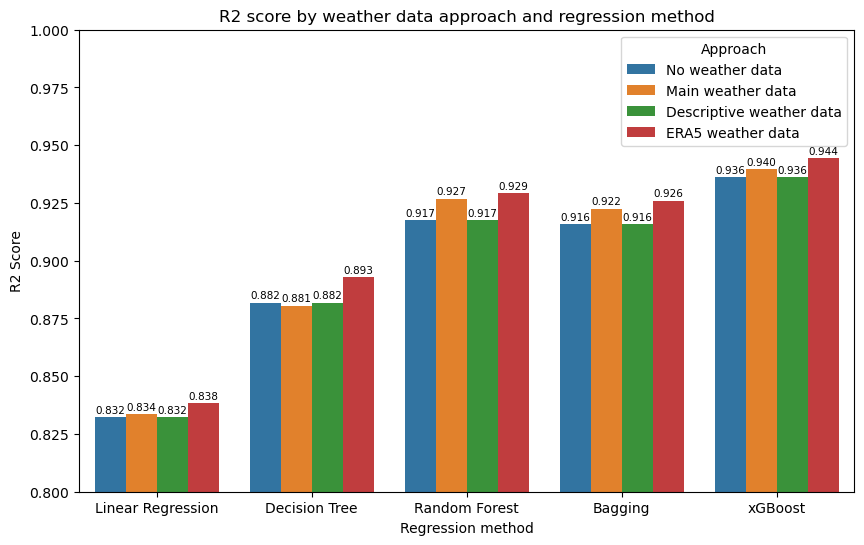

In [49]:
# R2 Data
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=evaluation, x='model', y='r2', hue='Approach')

plt.xlabel('Regression method')
plt.ylabel('R2 Score')

plt.ylim((0.8, 1.0))

# Add text labels on the bars (Powered by ChatGPT)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',  # Value on top of the bar
                (p.get_x() + p.get_width() / 2., p.get_height()),  # Positioning the text
                ha='center', va='center',   # Alignment
                fontsize=7.5, color='black',  # Text style
                xytext=(0, 5), textcoords='offset points')  # Offset for text
    
plt.title('R2 score by weather data approach and regression method')
plt.show()

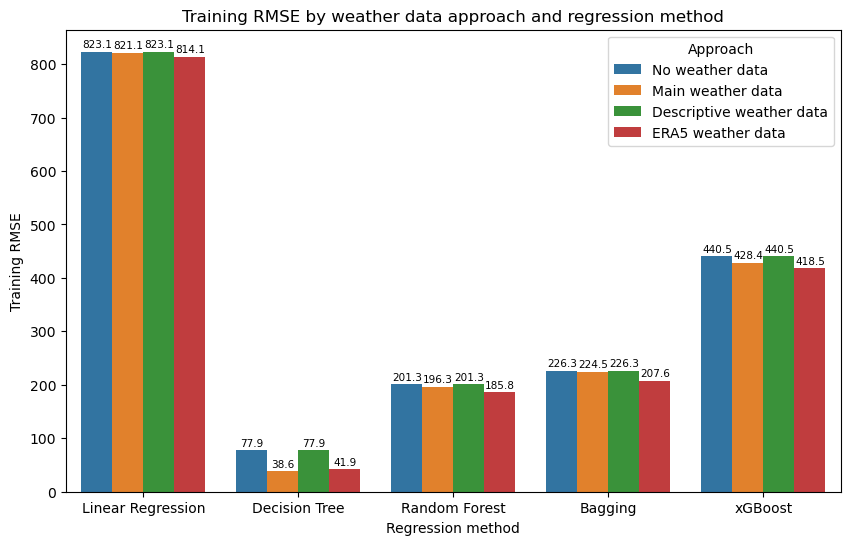

In [50]:
# Training RMSE
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=evaluation, x='model', y='train_rmse', hue='Approach')

plt.xlabel('Regression method')
plt.ylabel('Training RMSE')

# Add text labels on the bars (Powered by ChatGPT)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}',  # Value on top of the bar
                (p.get_x() + p.get_width() / 2., p.get_height()),  # Positioning the text
                ha='center', va='center',   # Alignment
                fontsize=7.5, color='black',  # Text style
                xytext=(0, 5), textcoords='offset points')  # Offset for text

plt.title('Training RMSE by weather data approach and regression method')
plt.show()

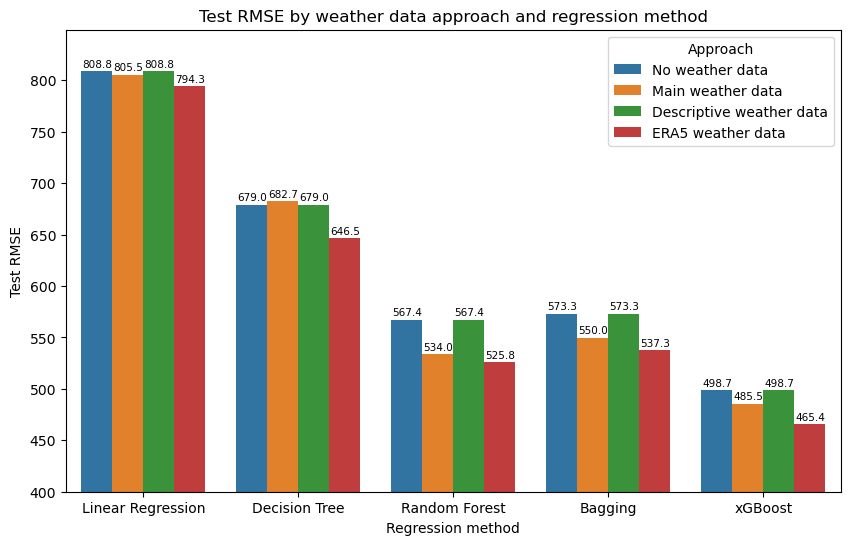

In [51]:
# Test RMSE
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=evaluation, x='model', y='test_rmse', hue='Approach')

plt.xlabel('Regression method')
plt.ylabel('Test RMSE')

# Add text labels on the bars (Powered by ChatGPT)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}',  # Value on top of the bar
                (p.get_x() + p.get_width() / 2., p.get_height()),  # Positioning the text
                ha='center', va='center',   # Alignment
                fontsize=7.5, color='black',  # Text style
                xytext=(0, 5), textcoords='offset points')  # Offset for text

plt.ylim(bottom=400)
plt.title('Test RMSE by weather data approach and regression method')

plt.show()

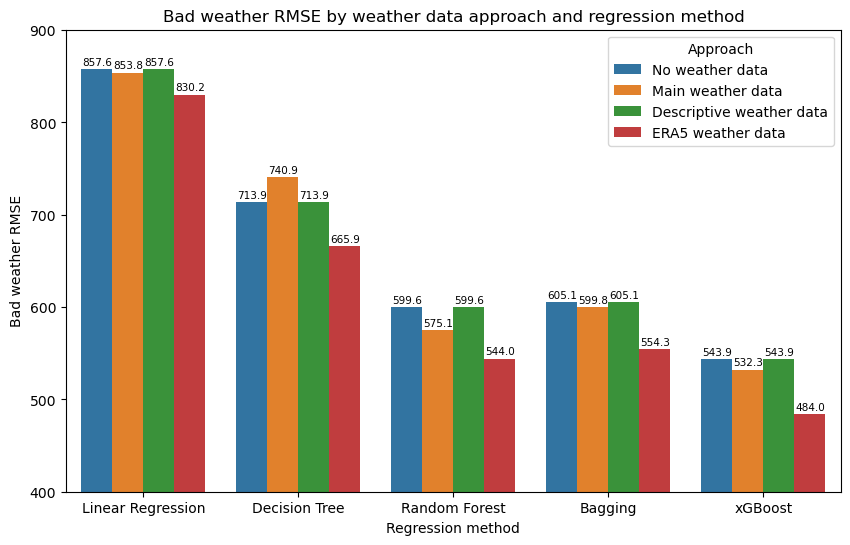

In [52]:
# Bad Weather RMSE
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=evaluation, x='model', y='bad_weather_rmse', hue='Approach')

plt.xlabel('Regression method')
plt.ylabel('Bad weather RMSE')

# Add text labels on the bars (Powered by ChatGPT)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}',  # Value on top of the bar
                (p.get_x() + p.get_width() / 2., p.get_height()),  # Positioning the text
                ha='center', va='center',   # Alignment
                fontsize=7.5, color='black',  # Text style
                xytext=(0, 5), textcoords='offset points')  # Offset for text

plt.ylim(bottom=400)
plt.title('Bad weather RMSE by weather data approach and regression method')

plt.show()